# MNIST 예측 해보기

`mnist.py`로 학습해서 저장해 둔 **`mnist_cnn.pt`**(학습된 가중치)를 불러와 손글씨 숫자를 맞혀 봅니다.

- 셀을 선택하고 **Shift+Enter**를 누르면 실행됩니다.
- 오른쪽 위 커널이 **Python (PyTorch)**인지 확인하세요.

## 1. 준비: GPU 확인

In [1]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch", torch.__version__, "| device:", device,
      torch.cuda.get_device_name(0) if device.type == "cuda" else "")

PyTorch 2.11.0+cu128 | device: cuda NVIDIA GeForce RTX 3080 Ti


## 2. 모델 불러오기

`.pt` 파일에는 모델 **구조가 아니라 가중치 숫자들만** 들어 있습니다.
그래서 `mnist.py`의 `Net` 클래스로 빈 모델을 만든 뒤 가중치를 채워 넣습니다.

In [2]:
from mnist import Net   # mnist.py 안의 모델 구조를 그대로 가져옴

model = Net().to(device)
state = torch.load("mnist_cnn.pt", map_location=device)
model.load_state_dict(state)
model.eval()

for name, w in state.items():
    print(f"{name:12s} {tuple(w.shape)}")
print("총 파라미터 수:", sum(w.numel() for w in state.values()))

conv1.weight (32, 1, 3, 3)
conv1.bias   (32,)
conv2.weight (64, 32, 3, 3)
conv2.bias   (64,)
fc1.weight   (128, 3136)
fc1.bias     (128,)
fc2.weight   (10, 128)
fc2.bias     (10,)
총 파라미터 수: 421642


## 3. 테스트 데이터 1만 장으로 정확도 재기

In [3]:
tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
test_ds = datasets.MNIST("data", train=False, download=True, transform=tf)
test_dl = torch.utils.data.DataLoader(test_ds, batch_size=1000)

correct = 0
with torch.no_grad():
    for x, y in test_dl:
        correct += (model(x.to(device)).argmax(1).cpu() == y).sum().item()
print(f"정확도: {100 * correct / len(test_ds):.2f}%")

정확도: 99.04%


## 4. 무작위 12장 그려보기

초록 = 맞힘, 빨강 = 틀림. 셀을 다시 실행하면 다른 그림이 나옵니다.

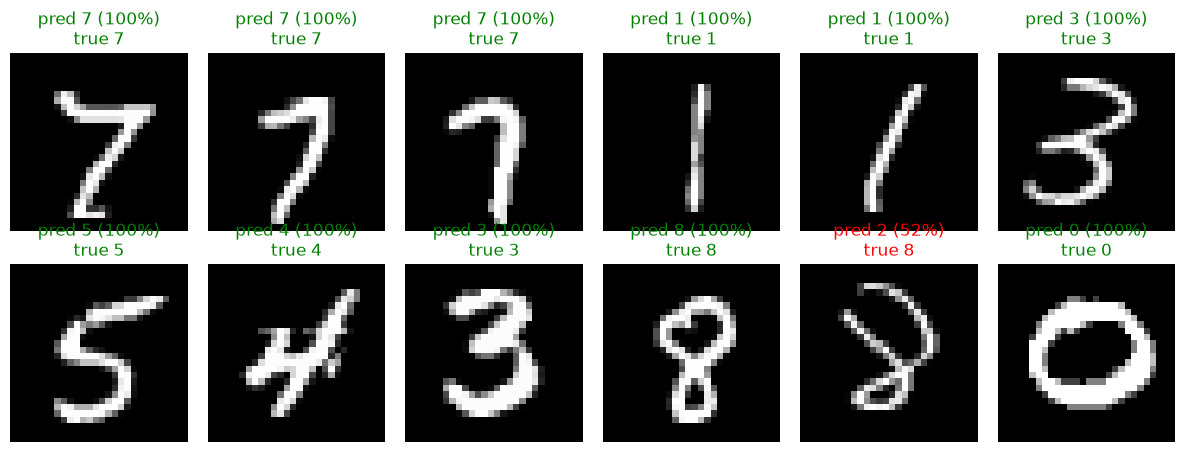

In [4]:
idx = torch.randint(len(test_ds), (12,))
x = torch.stack([test_ds[i][0] for i in idx])
y = [test_ds[i][1] for i in idx]
with torch.no_grad():
    prob = model(x.to(device)).softmax(1).cpu()

fig, axes = plt.subplots(2, 6, figsize=(12, 4.5))
for ax, img, t, p in zip(axes.flat, x, y, prob):
    pred = p.argmax().item()
    ax.imshow(img[0], cmap="gray")
    ax.set_title(f"pred {pred} ({p[pred]:.0%})\ntrue {t}", color="green" if pred == t else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()

## 5. 틀린 것만 20장 보기

테스트 1만 장 중 모델이 **틀린 그림**만 골라 무작위로 20장 보여줍니다.
제목: `pred` = 모델이 고른 숫자(확신도), `true` = 정답, `2nd` = 두 번째 후보. 다시 실행하면 다른 20장이 나옵니다.

틀린 개수: 96 / 10000


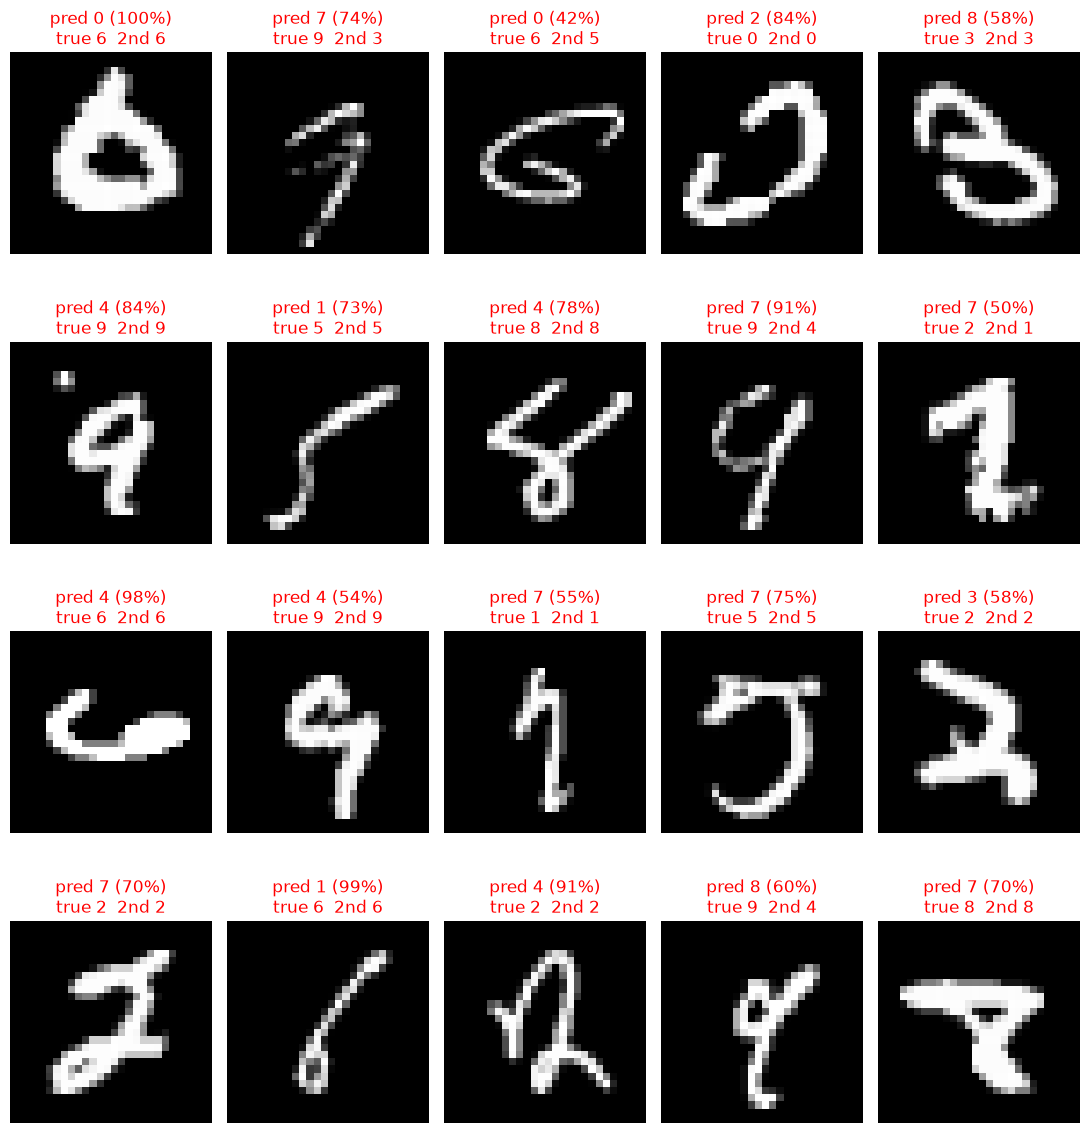

In [5]:
# 전체 테스트셋 예측을 한 번에 모음
preds, probs = [], []
with torch.no_grad():
    for x, _ in test_dl:
        p = model(x.to(device)).softmax(1).cpu()
        probs.append(p)
probs = torch.cat(probs)
preds = probs.argmax(1)
labels = test_ds.targets

wrong = (preds != labels).nonzero().flatten()
print(f"틀린 개수: {len(wrong)} / {len(test_ds)}")

pick = wrong[torch.randperm(len(wrong))[:20]]
fig, axes = plt.subplots(4, 5, figsize=(11, 12))
for ax, i in zip(axes.flat, pick.tolist()):
    top2 = probs[i].topk(2)
    ax.imshow(test_ds.data[i], cmap="gray")
    ax.set_title(f"pred {preds[i].item()} ({top2.values[0]:.0%})\n"
                 f"true {labels[i].item()}  2nd {top2.indices[1].item()}", color="red")
    ax.axis("off")
for ax in axes.flat[len(pick):]:
    ax.axis("off")
plt.tight_layout()
plt.show()

## 6. 혼동 행렬 (Confusion Matrix)

**행 = 정답**, **열 = 모델 예측**. 대각선이 맞힌 개수이고, 대각선 밖이 "무엇을 무엇으로 헷갈렸는지"입니다.
5번 셀에서 만든 `preds`, `labels`를 그대로 씁니다(5번을 먼저 실행하세요).

시각화 도구 두 가지로 그려 봅니다.
- **scikit-learn** `ConfusionMatrixDisplay`: 가장 표준적인 방법, 한 줄로 그림
- **seaborn** `heatmap`: 모양을 자유롭게 꾸밀 수 있음. 여기선 맞힌 칸(대각선)을 가려서 **틀린 것만** 강조

### 6-1. scikit-learn: 개수 / 비율

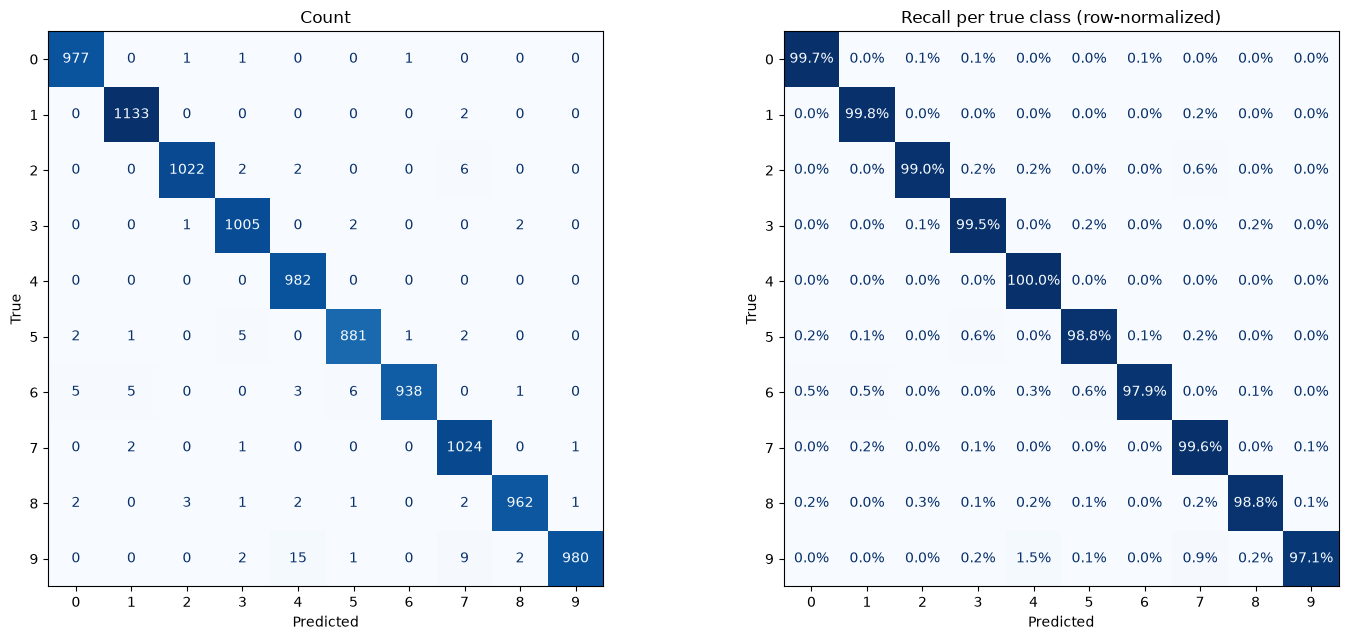

In [6]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

cm = confusion_matrix(labels, preds)

fig, axes = plt.subplots(1, 2, figsize=(15, 6.5))
ConfusionMatrixDisplay(cm, display_labels=range(10)).plot(ax=axes[0], cmap="Blues", colorbar=False)
axes[0].set_title("Count")
ConfusionMatrixDisplay.from_predictions(labels, preds, normalize="true", values_format=".1%",
                                        ax=axes[1], cmap="Blues", colorbar=False)
axes[1].set_title("Recall per true class (row-normalized)")
for ax in axes:
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
plt.tight_layout()
plt.show()

### 6-2. seaborn: 틀린 것만 강조

대각선(정답)을 가리면 색 범위가 오답 개수에 맞춰져서 작은 실수도 눈에 잘 띕니다.

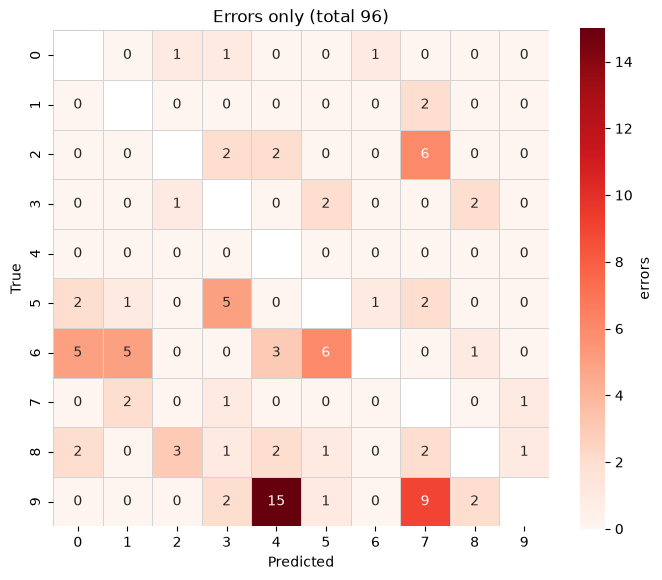

정답 9 -> 예측 4: 15번
정답 9 -> 예측 7: 9번
정답 6 -> 예측 5: 6번
정답 2 -> 예측 7: 6번
정답 6 -> 예측 1: 5번


In [7]:
import numpy as np
import seaborn as sns

errors = cm.copy()
np.fill_diagonal(errors, 0)

plt.figure(figsize=(8, 6.5))
sns.heatmap(errors, annot=True, fmt="d", cmap="Reds", mask=np.eye(10, dtype=bool),
            linewidths=0.5, linecolor="lightgray", square=True, cbar_kws={"label": "errors"})
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title(f"Errors only (total {errors.sum()})")
plt.show()

# 가장 많이 헷갈린 쌍 Top 5
top = np.dstack(np.unravel_index(np.argsort(errors, axis=None)[::-1][:5], errors.shape))[0]
for t, pr in top:
    print(f"정답 {t} -> 예측 {pr}: {errors[t, pr]}번")

### 6-3. 숫자별 성적표

- **precision**: 모델이 그 숫자라고 했을 때 맞은 비율
- **recall**: 실제 그 숫자를 찾아낸 비율 (위 비율 행렬의 대각선)
- **f1-score**: 둘의 조화 평균

In [8]:
print(classification_report(labels, preds, digits=4))

              precision    recall  f1-score   support

           0     0.9909    0.9969    0.9939       980
           1     0.9930    0.9982    0.9956      1135
           2     0.9951    0.9903    0.9927      1032
           3     0.9882    0.9950    0.9916      1010
           4     0.9781    1.0000    0.9889       982
           5     0.9888    0.9877    0.9882       892
           6     0.9979    0.9791    0.9884       958
           7     0.9799    0.9961    0.9879      1028
           8     0.9948    0.9877    0.9912       974
           9     0.9980    0.9713    0.9844      1009

    accuracy                         0.9904     10000
   macro avg     0.9905    0.9902    0.9903     10000
weighted avg     0.9905    0.9904    0.9904     10000



## 7. 혼동 행렬의 한 칸 들여다보기

6-2에서 빨갛게 보인 칸(예: 정답 9 → 예측 4)에 실제로 어떤 그림들이 들어있는지 봅니다.
5·6번 셀에서 만든 `probs`, `preds`, `labels`, `errors`를 씁니다.

- 모델이 **확신한 순서**로 정렬 → 앞쪽일수록 "자신 있게 틀린" 그림
- 제목: `pred` 확신도 / 정답 숫자에 준 확률(`true`)
- 맨 윗줄 **파란 제목**은 비교용: 같은 정답 숫자를 **맞힌** 그림들

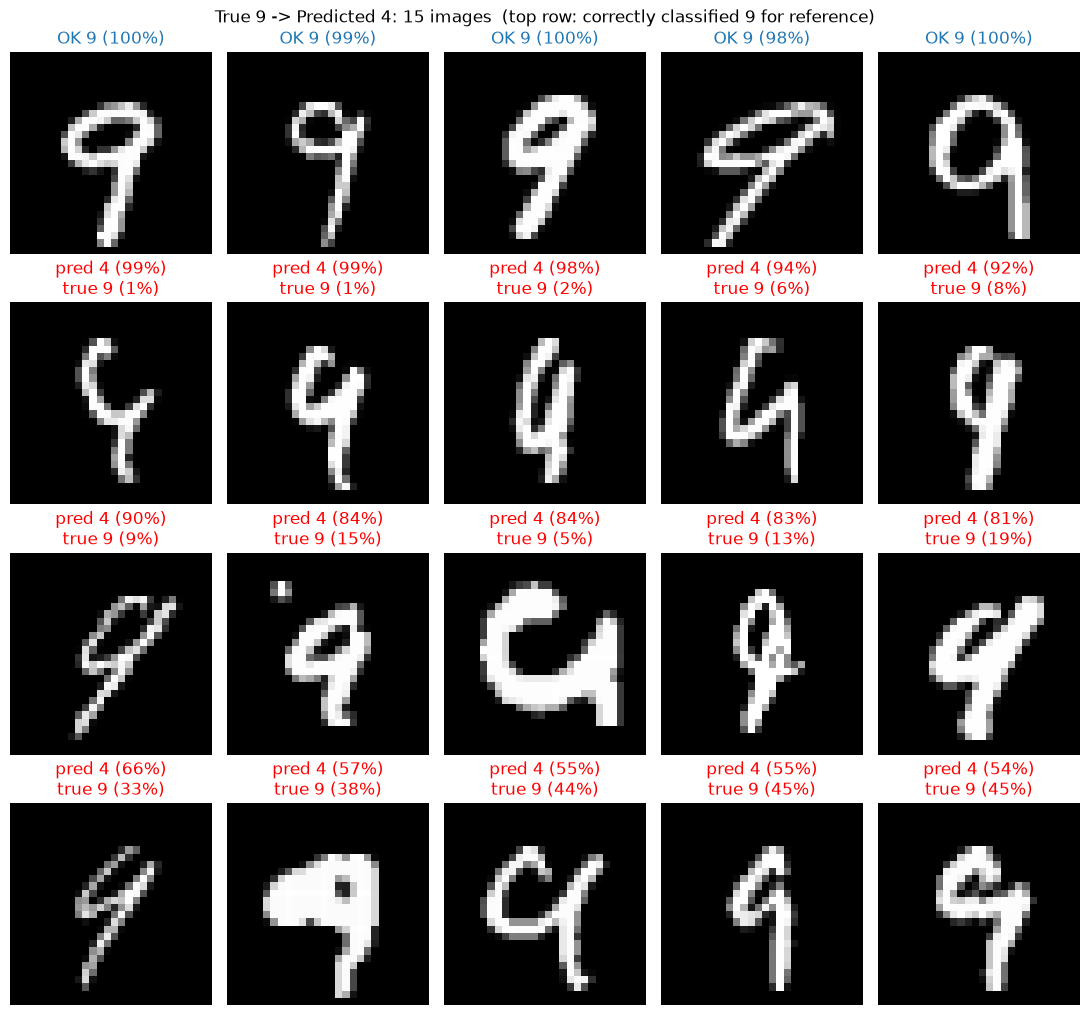

In [9]:
def show_cell(t, pr, max_n=20, n_ref=5):
    """정답 t 인데 pr 로 예측한 그림들 + 비교용으로 t 를 맞힌 그림 n_ref 장"""
    idx = ((labels == t) & (preds == pr)).nonzero().flatten()
    if len(idx) == 0:
        print(f"정답 {t} -> 예측 {pr}: 해당 없음")
        return
    idx = idx[probs[idx, pr].argsort(descending=True)][:max_n]   # 확신 높은 순
    ref = ((labels == t) & (preds == t)).nonzero().flatten()
    ref = ref[torch.randperm(len(ref))[:n_ref]]

    cols = 5
    rows = 1 + -(-len(idx) // cols)
    fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.6 * rows))
    for ax in axes.flat:
        ax.axis("off")
    for ax, i in zip(axes[0], ref.tolist()):
        ax.imshow(test_ds.data[i], cmap="gray")
        ax.set_title(f"OK {t} ({probs[i, t]:.0%})", color="tab:blue")
    for ax, i in zip(axes[1:].flat, idx.tolist()):
        ax.imshow(test_ds.data[i], cmap="gray")
        ax.set_title(f"pred {pr} ({probs[i, pr]:.0%})\ntrue {t} ({probs[i, t]:.0%})", color="red")
    fig.suptitle(f"True {t} -> Predicted {pr}: {len(idx)} images  (top row: correctly classified {t} for reference)")
    plt.tight_layout()
    plt.show()

# 가장 많이 헷갈린 칸을 자동으로 보여줌 (이 모델에선 9 -> 4)
t, pr = np.unravel_index(errors.argmax(), errors.shape)
show_cell(int(t), int(pr))

### 7-1. 다른 칸 골라 보기

드롭다운에서 칸을 고르면 바로 바뀝니다(오답이 있는 칸만, 많은 순). 드롭다운이 안 보이면 `show_cell(정답, 예측)`을 직접 호출하세요. 예: `show_cell(6, 5)`

In [10]:
import ipywidgets as widgets

pairs = sorted(((int(errors[a, b]), a, b) for a in range(10) for b in range(10) if errors[a, b]), reverse=True)
options = [(f"정답 {a} → 예측 {b}  ({n}개)", (a, b)) for n, a, b in pairs]
widgets.interact(lambda cell: show_cell(*cell),
                 cell=widgets.Dropdown(options=options, description="칸",
                                       layout=widgets.Layout(width="280px")));

interactive(children=(Dropdown(description='칸', layout=Layout(width='280px'), options=(('정답 9 → 예측 4  (15개)', …